# Your first bubble simulation

Simulate a gas microbubble driven by a short ultrasound pulse. You run a preset in five lines, build the same model from its parts, and then compile the simulation once so that every later run takes milliseconds.

Each example in this series runs as a plain Python script or as a notebook. The figures use jbubble's Matplotlib style: the bubble is blue, comparisons use the next colours in the cycle, and the acoustic drive is grey on its own axes.

In [ ]:
# Install jbubble on Google Colab, or anywhere it's missing.
import importlib.util

if importlib.util.find_spec("jbubble") is None:
    %pip install --quiet "jbubble[examples]==0.2.0"

In [1]:
import time

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

plt.style.use("jbubble.style.light")
DRIVE = "#8c959f"  # neutral grey for the acoustic drive in the light theme

## Run a preset

A preset returns an equation of motion, `eom`, and a driving pulse. `free_bubble` describes an uncoated 2 µm air bubble in water with the Keller-Miksis equation, driven by a five-cycle, 1 MHz, 100 kPa tone burst. `run_simulation` integrates the equation of motion and returns the trajectory in SI units.

In [2]:
from jbubble import run_simulation
from jbubble.utils.presets import free_bubble

eom, pulse = free_bubble(R0=2e-6, freq=1e6, pressure=100e3)
result = run_simulation(eom, pulse)
print(f"Peak radius: {result.radius.max() * 1e6:.2f} µm from R0 = 2 µm")

Peak radius: 3.19 µm from R0 = 2 µm


The result holds the sample times `result.ts`, the radius `result.radius`, the wall velocity `result.radial_velocity`, and the pressure that drives the bubble, `result.driving_pressure`. By default, `run_simulation` records 1024 samples from $t = 0$ to `pulse.t_end`, which is twice the pulse duration after the pulse starts, so you also see the bubble ring down after the drive stops.

Plot the drive above the radius, which you divide by the equilibrium radius $R_0$. The radius doesn't follow the drive like a sine wave. A 2 µm bubble in water resonates near 2 MHz, so the 1 MHz drive also excites its second harmonic, and the bubble keeps ringing at its resonance frequency after the pulse ends.

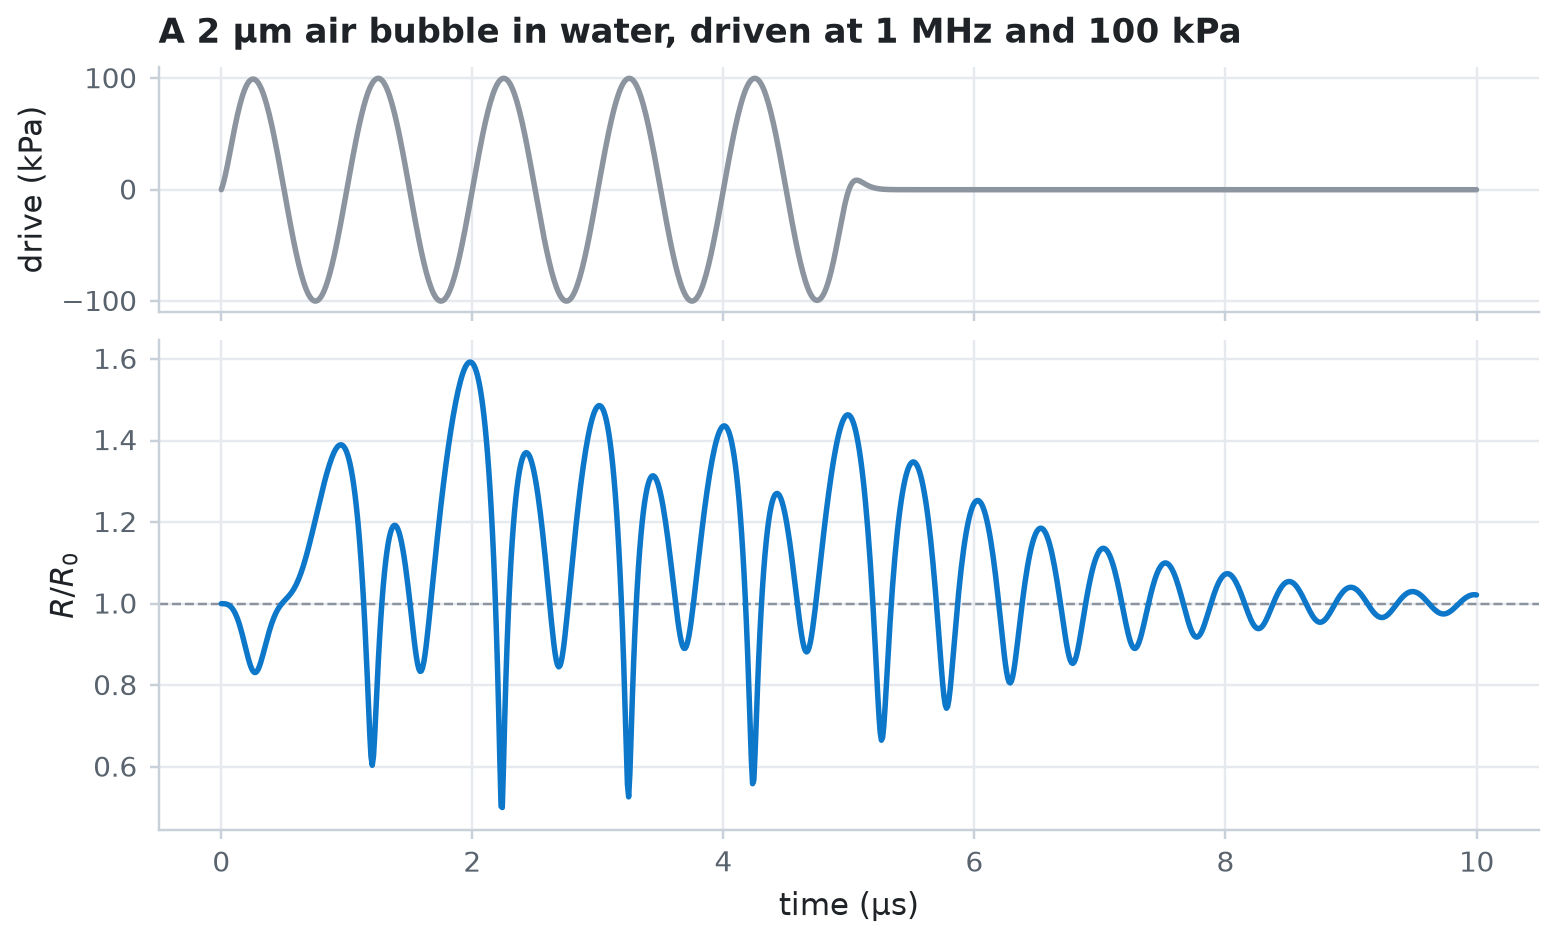

In [3]:
t_us = result.ts * 1e6
fig, (ax_p, ax_r) = plt.subplots(
    2, 1, figsize=(7.0, 4.2), sharex=True, height_ratios=[1, 2]
)
ax_p.plot(t_us, result.driving_pressure / 1e3, color=DRIVE)
ax_p.set_ylabel("drive (kPa)")
ax_p.set_title("A 2 µm air bubble in water, driven at 1 MHz and 100 kPa")
ax_r.axhline(1.0, color=DRIVE, lw=0.8, ls="--")
ax_r.plot(t_us, result.radius / eom.R0, color="C0")
ax_r.set_xlabel("time (µs)")
ax_r.set_ylabel("$R / R_0$")
plt.show()

## Build the same model from parts

An equation of motion combines three physical parts: a gas model for the pressure inside the bubble, a shell model for the coating at its wall, and a medium model for the liquid around it. A pulse combines a carrier shape with a frequency, an amplitude, and a number of cycles. The preset above assembles exactly these parts.

In [4]:
from jbubble.bubble.eom import KellerMiksis
from jbubble.bubble.gas import PolytropicGas
from jbubble.bubble.medium import NewtonianMedium
from jbubble.bubble.shell import NoShell
from jbubble.pulse import ToneBurst
from jbubble.pulse.shapes import Sine

water = KellerMiksis(
    gas=PolytropicGas(gamma=1.4),  # air, compressed adiabatically
    shell=NoShell(sigma=0.072),  # surface tension of water [N/m]
    medium=NewtonianMedium(
        mu=1e-3,  # viscosity of water [Pa s]
        rho_L=998.0,  # liquid density [kg/m³]
        c_L=1500.0,  # speed of sound in the liquid [m/s]
    ),
    R0=2e-6,  # equilibrium radius [m]
    P_amb=101325.0,  # ambient pressure [Pa]
)
burst = ToneBurst(freq=1e6, pressure=100e3, shape=Sine(), cycle_num=5)

by_hand = run_simulation(water, burst)
print(
    "Same trajectory as the preset:", bool(jnp.allclose(by_hand.radius, result.radius))
)
print(water)

Same trajectory as the preset: True
KellerMiksis(
  gas=PolytropicGas(gamma=ConstantProperty(val=1.4)),
  shell=NoShell(sigma=ConstantProperty(val=0.072)),
  medium=NewtonianMedium(
    mu=ConstantProperty(val=0.001), rho_L=998.0, c_L=1500.0
  ),
  R0=2e-06,
  P_amb=101325.0
)


Models are immutable [Equinox](https://docs.kidger.site/equinox/) modules, so you change a part by building a new model. `eqx.tree_at` copies a model with one part replaced. Here the liquid becomes four times as viscous as water, which damps the oscillation and lowers the peak radius.

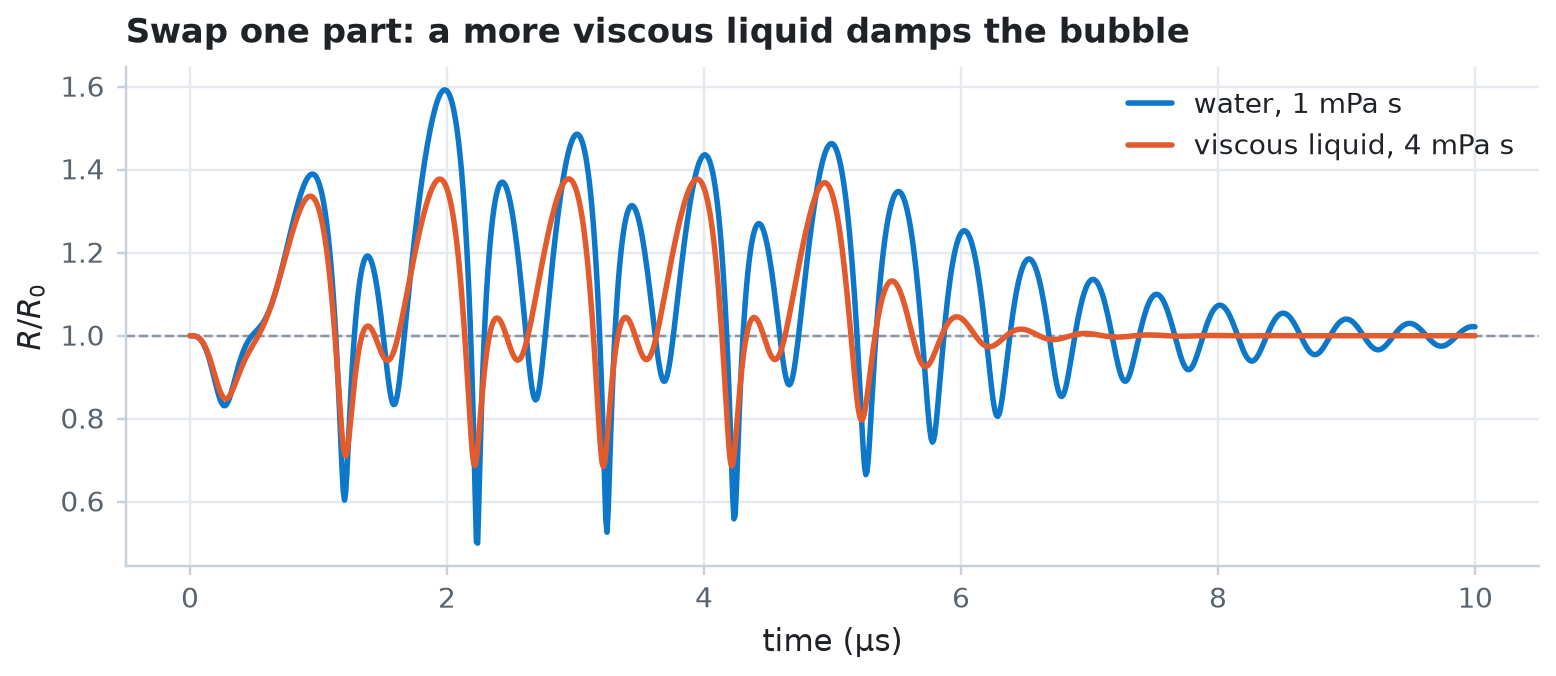

In [5]:
viscous = eqx.tree_at(lambda m: m.medium, water, NewtonianMedium(mu=4e-3))
damped = run_simulation(viscous, burst)

fig, ax = plt.subplots(figsize=(7.0, 3.0))
ax.axhline(1.0, color=DRIVE, lw=0.8, ls="--")
ax.plot(by_hand.ts * 1e6, by_hand.radius / water.R0, color="C0", label="water, 1 mPa s")
ax.plot(
    damped.ts * 1e6,
    damped.radius / water.R0,
    color="C1",
    label="viscous liquid, 4 mPa s",
)
ax.set_xlabel("time (µs)")
ax.set_ylabel("$R / R_0$")
ax.set_title("Swap one part: a more viscous liquid damps the bubble")
ax.legend(loc="upper right")
plt.show()

## Compile once, run many times

`jax.jit` compiles a function the first time you call it and reuses the compiled code for every later call whose arguments have the same structure: the same model classes and the same array shapes. Parameter values, such as the pressure, can change freely. A different structure, such as a `Square` carrier in place of `Sine`, triggers a new compilation.

JAX runs asynchronously, so call `block_until_ready()` before you stop the clock.

In [6]:
sim = jax.jit(run_simulation)

start = time.perf_counter()
sim(water, burst).radius.block_until_ready()
first_call = time.perf_counter() - start

pressures = [50e3, 100e3, 150e3, 200e3, 250e3]
later_calls = []
for pressure in pressures:
    drive = ToneBurst(freq=1e6, pressure=pressure, shape=Sine(), cycle_num=5)
    start = time.perf_counter()
    run = sim(water, drive)
    run.radius.block_until_ready()
    later_calls.append(time.perf_counter() - start)
    peak = float(run.radius.max() / water.R0)
    print(f"{pressure / 1e3:5.0f} kPa: peak R/R0 = {peak:.2f}")

print(f"First call (trace, compile, and run): {first_call * 1e3:.0f} ms")
print(
    f"Later calls (run only): {min(later_calls) * 1e3:.1f}"
    f" to {max(later_calls) * 1e3:.1f} ms each"
)

   50 kPa: peak R/R0 = 1.25
  100 kPa: peak R/R0 = 1.59
  150 kPa: peak R/R0 = 2.01
  200 kPa: peak R/R0 = 3.75
  250 kPa: peak R/R0 = 4.07
First call (trace, compile, and run): 1646 ms
Later calls (run only): 5.6 to 8.2 ms each
